In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os 

In [3]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 16,
                     'axes.labelsize': 14,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

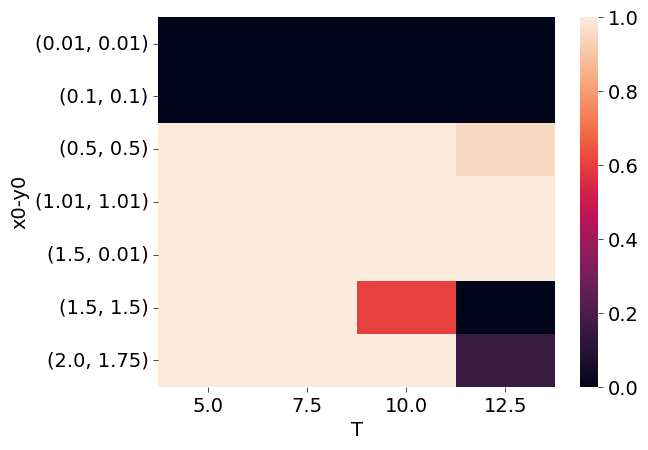

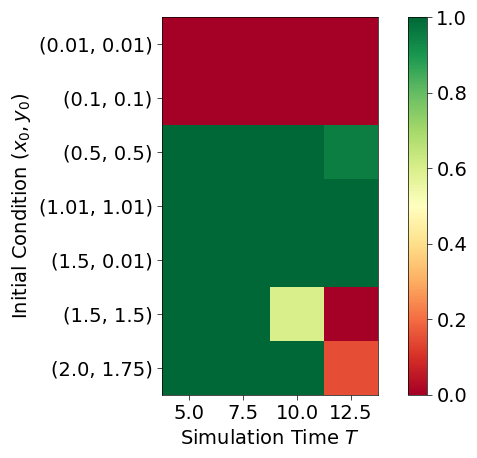

In [4]:
results1 = pd.read_csv("results_no_reg.csv")
results2 = pd.read_csv("results_no_reg_T12_5.csv")

results = pd.concat([results1, results2])
results.to_csv("results_no_reg_full.csv", index=False)

table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["x0-y0"],
                        columns=["T"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

table.to_csv("results_no_reg_pivot.csv")

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns, rotation=0)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $(x_0, y_0)$')


plt.tight_layout()
plt.show()

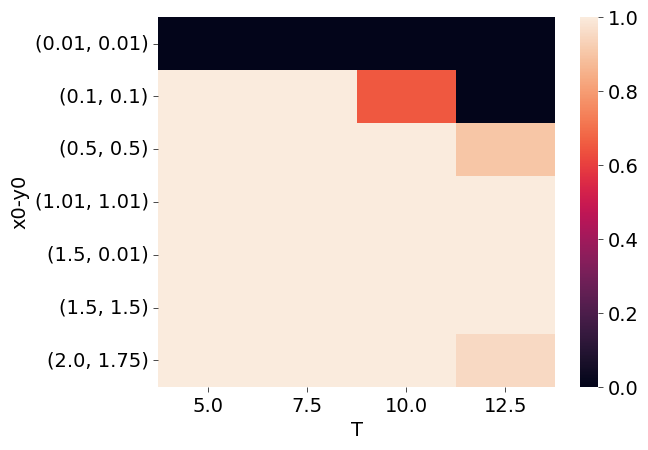

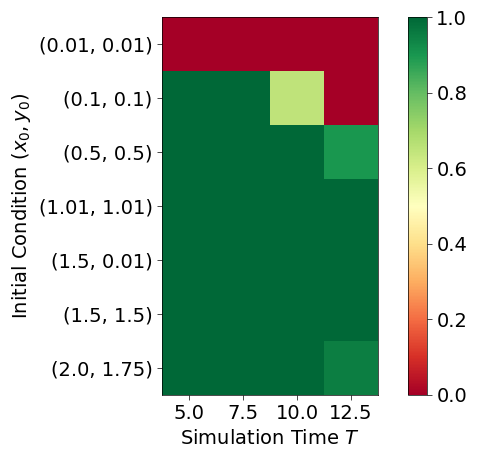

In [5]:
# results = pd.read_csv("results_reg_full_new.csv")
results = pd.read_csv("results_reg_full_c0_1_0_25.csv")


table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["x0-y0"],
                        columns=["T"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

table.to_csv("results_reg_pivot.csv")

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns, rotation=0)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $(x_0, y_0)$')


plt.tight_layout()
plt.show()

/tmp/ipykernel_6323/4004001450.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
/tmp/ipykernel_6323/4004001450.py:2:

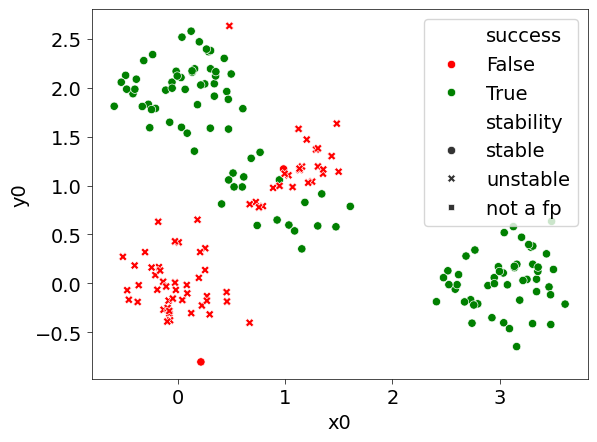

/tmp/ipykernel_6323/4004001450.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
/tmp/ipykernel_6323/4004001450.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediat

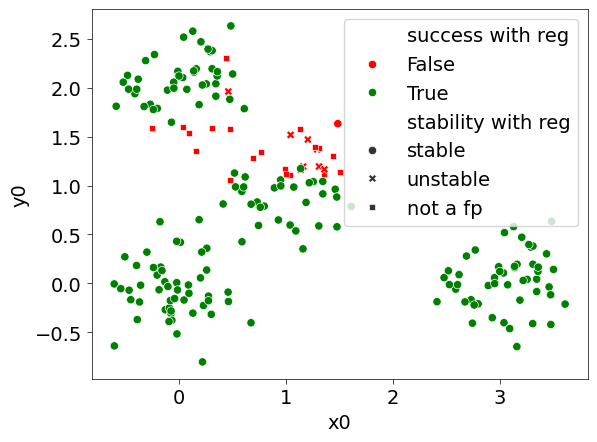

In [6]:
table_no_reg = pd.read_csv("convergence_points.csv")
table_no_reg["stability"].loc[(table_no_reg["stability"] == "unstable") & (table_no_reg["success"] == True)] = "not a fp"
table_no_reg["x0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_no_reg["y0"] = table_no_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_no_reg["xT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[0])
table_no_reg["yT"] = table_no_reg["converged to"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}

plt.figure()
sns.scatterplot(data=table_no_reg, x="x0", y="y0", hue="success", style="stability", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

table_reg = pd.read_csv("convergence_points_reg.csv")
table_reg["stability with reg"].fillna(value="not a fp", inplace=True)
table_reg["stability with reg"].loc[(table_reg["stability with reg"] == "unstable") & (table_reg["success with reg"] == True)] = "not a fp"
table_reg["x0"] = table_reg["(x0, y0)"].apply(lambda row: eval(row)[0])
table_reg["y0"] = table_reg["(x0, y0)"].apply(lambda row: eval(row)[1])
table_reg["xT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[0])
table_reg["yT"] = table_reg["converged to with reg"].apply(lambda row: eval(row)[1])

plt.figure()
sns.scatterplot(data=table_reg, x="x0", y="y0", hue="success with reg", style="stability with reg", palette=colors, style_order=["stable", "unstable", "not a fp"])
plt.show()

T-x0-y0 7.5-(0.1, 0.1), regularizing stability around the fixed point


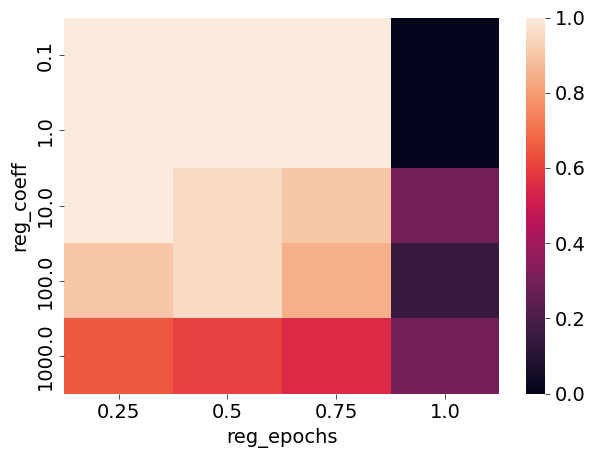

In [7]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}

# results = pd.read_csv("results_linear_decay_new.csv")
results = pd.read_csv("results_reg_combo.csv")

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)

results["T-x0-y0"] = results["T"].astype(str) + "-" + results["x0-y0"].astype(str) 

for settings in results["T-x0-y0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-x0-y0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")

        table.to_csv(f"{dirname}/2d_toy_example_results_{regularization}_settingsT-y0_{settings}.csv")


        sns.heatmap(table, vmin=0, vmax=1)
        # plt.title(f"T-x0-y0 {settings}, {regularization_names[regularization]}")
        print(f"T-x0-y0 {settings}, {regularization_names[regularization]}")
        plt.tight_layout()
        plt.savefig(f"{dirname}/2d_toy_example_results_{regularization}_settingsT-y0_{settings}.png")
        plt.show()
        